# Statistical Analysis: Inpainting Area vs Metric Performance
## CSE-498R Directed Research — Week 6

**Research Question:**
> *How does the inpainting mask coverage area (% of image) affect reconstruction quality (PSNR, SSIM, LPIPS) across Methods A, B, and C?*

**What this notebook does:**
1. Loads your existing results CSV from the 200-image evaluation
2. Performs correlation analysis (Pearson + Spearman) between area and each metric
3. Bins images into area groups and compares metric distributions
4. Finds the **critical threshold** where quality drops significantly
5. Fits regression curves to quantify the area-metric relationship
6. Tests statistical significance (t-tests, ANOVA)
7. Produces publication-ready figures and a summary table

**Novelty angle for your paper:** You can show that inpainting quality degradation follows a measurable, non-linear pattern with a specific area threshold — and that progressive removal (Method B/C) delays this degradation compared to single-shot (Method A).

## Cell 1 — Install & Import

In [ ]:
!pip install scipy scikit-learn pandas matplotlib seaborn statsmodels -q
print('Done!')

Done!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistics
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {'A': '#e07070', 'B': '#5b9bd5', 'C': '#70c775'}
PLOT_DIR = Path('stat_plots')
PLOT_DIR.mkdir(exist_ok=True)

print('All imports ready!')

All imports ready!


## Cell 1b — (Optional) Upload Image ZIP
If any cell in this notebook needs to load images directly, upload your ZIP file here.  
**Skip this cell if you only need the CSV-based statistical analysis.**

In [ ]:
# ── (Optional) Upload image ZIP from laptop ───────────────────────────────────
# Run this cell only if you want to load images from a ZIP file.
# Skip it if you only need the CSV-based analysis.

import zipfile, os
from google.colab import files as colab_files

print('📦 Please upload your image ZIP file:')
zip_upload = colab_files.upload()

zip_files = [name for name in zip_upload.keys() if name.endswith('.zip')]
if not zip_files:
    raise ValueError('No ZIP file uploaded. Please upload a .zip file.')

zip_filename = zip_files[0]
IMAGE_DIR = '/content/images_extracted'
os.makedirs(IMAGE_DIR, exist_ok=True)

# Write and extract
with open(zip_filename, 'wb') as f:
    f.write(zip_upload[zip_filename])

with zipfile.ZipFile(zip_filename, 'r') as zf:
    zf.extractall(IMAGE_DIR)

all_images = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))]
print(f'\n✅ Extracted {len(all_images)} images to: {IMAGE_DIR}')
print(f'First 5: {all_images[:5]}')
print(f'\nUse IMAGE_DIR variable to reference image paths in downstream cells.')

📦 Please upload your image ZIP file:


Saving coco_200_persons.zip to coco_200_persons (1).zip

✅ Extracted 200 images to: /content/images_extracted
First 5: ['000000558114.jpg', '000000239717.jpg', '000000278848.jpg', '000000514508.jpg', '000000343561.jpg']

Use IMAGE_DIR variable to reference image paths in downstream cells.


## Cell 2 — Upload Your Results CSV
**Click the upload button below to upload your CSV file directly from your laptop.**

In [ ]:
# ── Upload your CSV file from laptop ─────────────────────────────────────────
from google.colab import files
import io

print('📂 Please upload your results CSV file:')
uploaded = files.upload()

# Auto-detect the uploaded CSV
csv_files = [name for name in uploaded.keys() if name.endswith('.csv')]
if not csv_files:
    raise ValueError('No CSV file uploaded. Please upload a .csv file.')

csv_filename = csv_files[0]
print(f'\n✅ Loaded: {csv_filename}')

df = pd.read_csv(io.BytesIO(uploaded[csv_filename]))

print(f'Loaded {len(df)} rows')
print(f'Columns: {list(df.columns)}')
df.head()

📂 Please upload your results CSV file:


Saving metrics.csv to metrics (2).csv

✅ Loaded: metrics (2).csv
Loaded 200 rows
Columns: ['image', 'n_persons', 'A_PSNR', 'A_SSIM', 'A_LPIPS', 'A_mask_pct', 'A_time_s', 'B_PSNR', 'B_SSIM', 'B_LPIPS', 'B_mask_pct', 'B_time_s', 'status']


,image,n_persons,A_PSNR,A_SSIM,A_LPIPS,A_mask_pct,A_time_s,B_PSNR,B_SSIM,B_LPIPS,B_mask_pct,B_time_s,status
0,000000001000.jpg,8,12.698,0.4736,0.5782,46.5,1.26,12.649,0.4796,0.5253,46.5,4.0,ok
1,000000002685.jpg,-1,-,-,-,-,-,-,-,-,-,-,error
2,000000004134.jpg,-1,-,-,-,-,-,-,-,-,-,-,error
3,000000005001.jpg,8,11.467,0.4823,0.4273,57.7,0.2,11.489,0.5041,0.4059,57.7,1.34,ok
4,000000005193.jpg,-1,-,-,-,-,-,-,-,-,-,-,error


## Cell 3 — Data Cleaning & Column Standardisation
This cell auto-detects your column names so the analysis works regardless of slight naming differences.

In [ ]:
# ── Auto-detect mask coverage column ─────────────────────────────────────────
coverage_candidates = [c for c in df.columns if 'mask' in c.lower() or 'coverage' in c.lower() or 'area' in c.lower()]
print('Coverage column candidates:', coverage_candidates)

# Pick the first match or let user override
COVERAGE_COL = coverage_candidates[0] if coverage_candidates else 'mask_coverage_%'
print(f'Using coverage column: "{COVERAGE_COL}"')

# ── Rename for convenience ────────────────────────────────────────────────────
df = df.rename(columns={COVERAGE_COL: 'coverage'})

# ── Ensure numeric ────────────────────────────────────────────────────────────
metric_cols = [c for c in df.columns if any(m in c for m in ['PSNR','SSIM','LPIPS','time'])]
for col in metric_cols + ['coverage']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Drop rows with missing metrics ───────────────────────────────────────────
before = len(df)
df = df.dropna(subset=['coverage'] + metric_cols)
print(f'Dropped {before - len(df)} rows with missing values. Remaining: {len(df)}')

# ── Confirm methods present ───────────────────────────────────────────────────
methods = []
for m in ['A','B','C']:
    if f'{m}_PSNR' in df.columns:
        methods.append(m)
print(f'Methods found: {methods}')

# ── Basic stats ───────────────────────────────────────────────────────────────
print('\n--- COVERAGE STATISTICS ---')
print(df['coverage'].describe().round(3))

Coverage column candidates: ['A_mask_pct', 'B_mask_pct']
Using coverage column: "A_mask_pct"
Dropped 122 rows with missing values. Remaining: 78
Methods found: ['A', 'B']

--- COVERAGE STATISTICS ---
count    78.000
mean     40.554
std      16.556
min      12.310
25%      27.625
50%      36.730
75%      53.635
max      87.200
Name: coverage, dtype: float64


## Cell 4 — Area Binning: Divide Images into 4 Groups

We split all images into 4 groups by mask coverage:
- **Low** (0–15%): small objects removed
- **Medium** (15–30%): moderate removal
- **High** (30–50%): large removal
- **Very High** (>50%): extreme removal (most of the image masked)

**Why this matters:** If quality drops consistently as we move from Low → Very High, that proves area is a key determinant of inpainting quality — which is a novel, quantified finding.

Images per area group:
  Low         : 1 images
  Medium      : 25 images
  High        : 29 images
  Very High   : 23 images


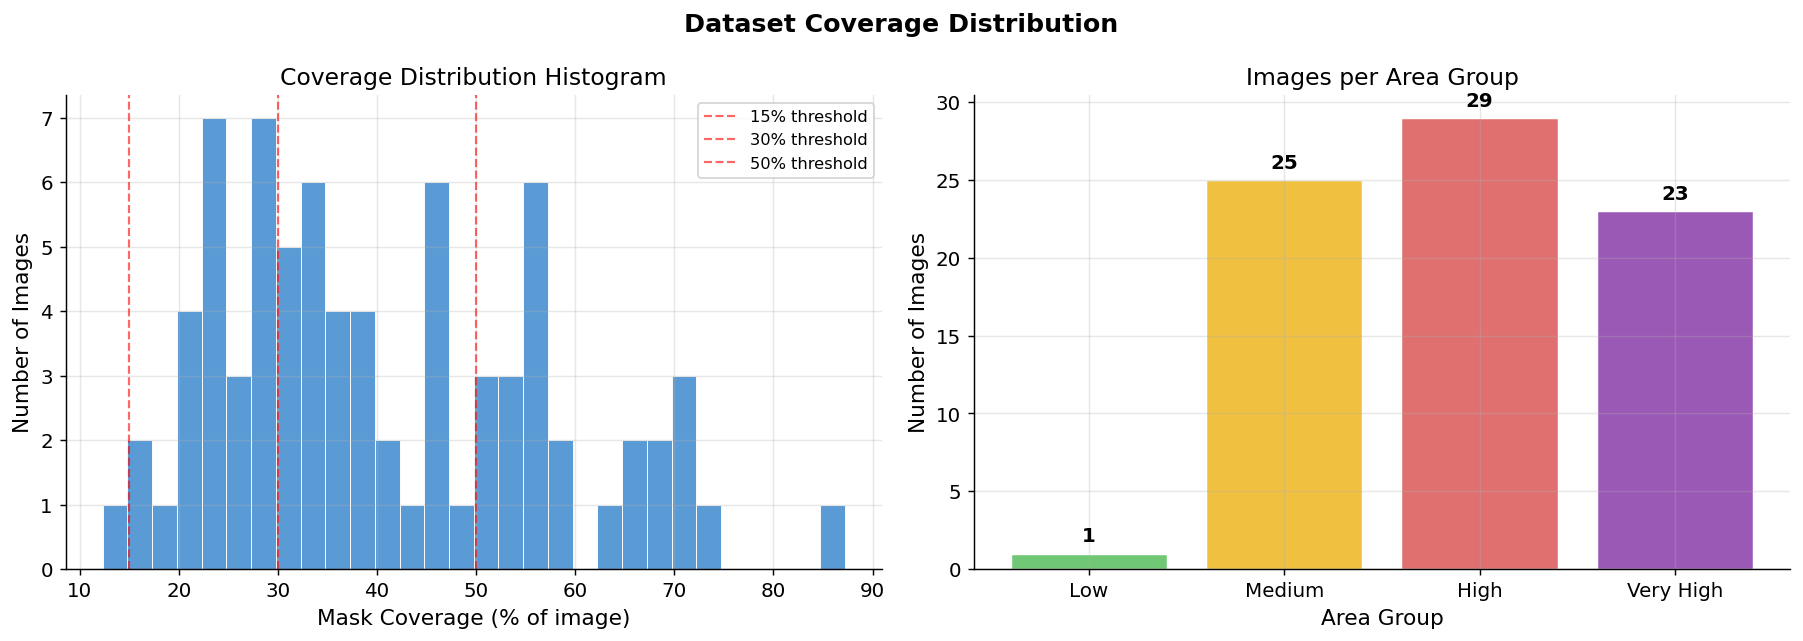

Saved: 01_coverage_distribution.png


In [ ]:
# ── Define bins ───────────────────────────────────────────────────────────────
BINS   = [0, 15, 30, 50, 100]
LABELS = ['Low\n(0–15%)', 'Medium\n(15–30%)', 'High\n(30–50%)', 'Very High\n(>50%)']
SHORT  = ['Low', 'Medium', 'High', 'Very High']

df['area_group'] = pd.cut(df['coverage'], bins=BINS, labels=SHORT, right=True)

# Count per group
group_counts = df['area_group'].value_counts().sort_index()
print('Images per area group:')
for g, n in group_counts.items():
    print(f'  {g:12s}: {n} images')

# ── Plot: Distribution of coverage ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Coverage Distribution', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['coverage'], bins=30, color='#5b9bd5', edgecolor='white', linewidth=0.5)
for b in BINS[1:-1]:
    axes[0].axvline(b, color='red', linestyle='--', alpha=0.6, linewidth=1.2, label=f'{b}% threshold')
axes[0].set_xlabel('Mask Coverage (% of image)')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Coverage Distribution Histogram')
axes[0].legend(fontsize=9)

# Bar chart of group counts
bar_colors = ['#70c775','#f0c040','#e07070','#9b59b6']
bars = axes[1].bar(SHORT, group_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, n in zip(bars, group_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(n), ha='center', va='bottom', fontweight='bold')
axes[1].set_xlabel('Area Group')
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Images per Area Group')

plt.tight_layout()
plt.savefig(PLOT_DIR/'01_coverage_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 01_coverage_distribution.png')

## Cell 5 — Correlation Analysis

**Pearson correlation** measures linear relationship.  
**Spearman correlation** measures rank/monotonic relationship (more robust).  

For each method (A, B, C) and each metric (PSNR, SSIM, LPIPS), we compute both.

**Expected finding:** PSNR and SSIM should show strong *negative* correlation with coverage (more area = worse quality). LPIPS should show *positive* correlation (more area = worse perceptual quality = higher LPIPS).

In [ ]:
print('='*72)
print('  CORRELATION: Mask Coverage % vs Each Metric')
print('='*72)
print(f'{"Method":<8} {"Metric":<12} {"Pearson r":>10} {"p-value":>10} {"Spearman ρ":>12} {"p-value":>10}  Interpretation')
print('-'*72)

corr_results = []

for method in methods:
    for metric in ['PSNR', 'SSIM', 'LPIPS']:
        col = f'{method}_{metric}'
        if col not in df.columns:
            continue
        x = df['coverage'].values
        y = df[col].values
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]

        pr, pp = pearsonr(x, y)
        sr, sp = spearmanr(x, y)

        # Significance stars
        def sig(p):
            if p < 0.001: return '***'
            if p < 0.01:  return '**'
            if p < 0.05:  return '*'
            return 'ns'

        # Direction interpretation
        if metric == 'LPIPS':
            direction = 'worse with more area' if sr > 0.3 else ('better with more area' if sr < -0.3 else 'weak/no trend')
        else:
            direction = 'worse with more area' if sr < -0.3 else ('better with more area' if sr > 0.3 else 'weak/no trend')

        print(f'{method:<8} {metric:<12} {pr:>+10.4f} {f"{pp:.4f}{sig(pp)}":>10} {sr:>+12.4f} {f"{sp:.4f}{sig(sp)}":>10}  {direction}')

        corr_results.append({
            'method': method, 'metric': metric,
            'pearson_r': round(pr,4), 'pearson_p': round(pp,4),
            'spearman_r': round(sr,4), 'spearman_p': round(sp,4),
        })

print('='*72)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')

corr_df = pd.DataFrame(corr_results)

  CORRELATION: Mask Coverage % vs Each Metric
Method   Metric        Pearson r    p-value   Spearman ρ    p-value  Interpretation
------------------------------------------------------------------------
A        PSNR            -0.2917   0.0096**      -0.2845    0.0116*  weak/no trend
A        SSIM            -0.4956  0.0000***      -0.4609  0.0000***  worse with more area
A        LPIPS           +0.5273  0.0000***      +0.4683  0.0000***  worse with more area
B        PSNR            -0.3303   0.0031**      -0.3101   0.0057**  worse with more area
B        SSIM            -0.5043  0.0000***      -0.4658  0.0000***  worse with more area
B        LPIPS           +0.5535  0.0000***      +0.4734  0.0000***  worse with more area
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


## Cell 6 — Scatter Plots with Regression Lines
Visual proof of the area-metric relationship for all methods and metrics.

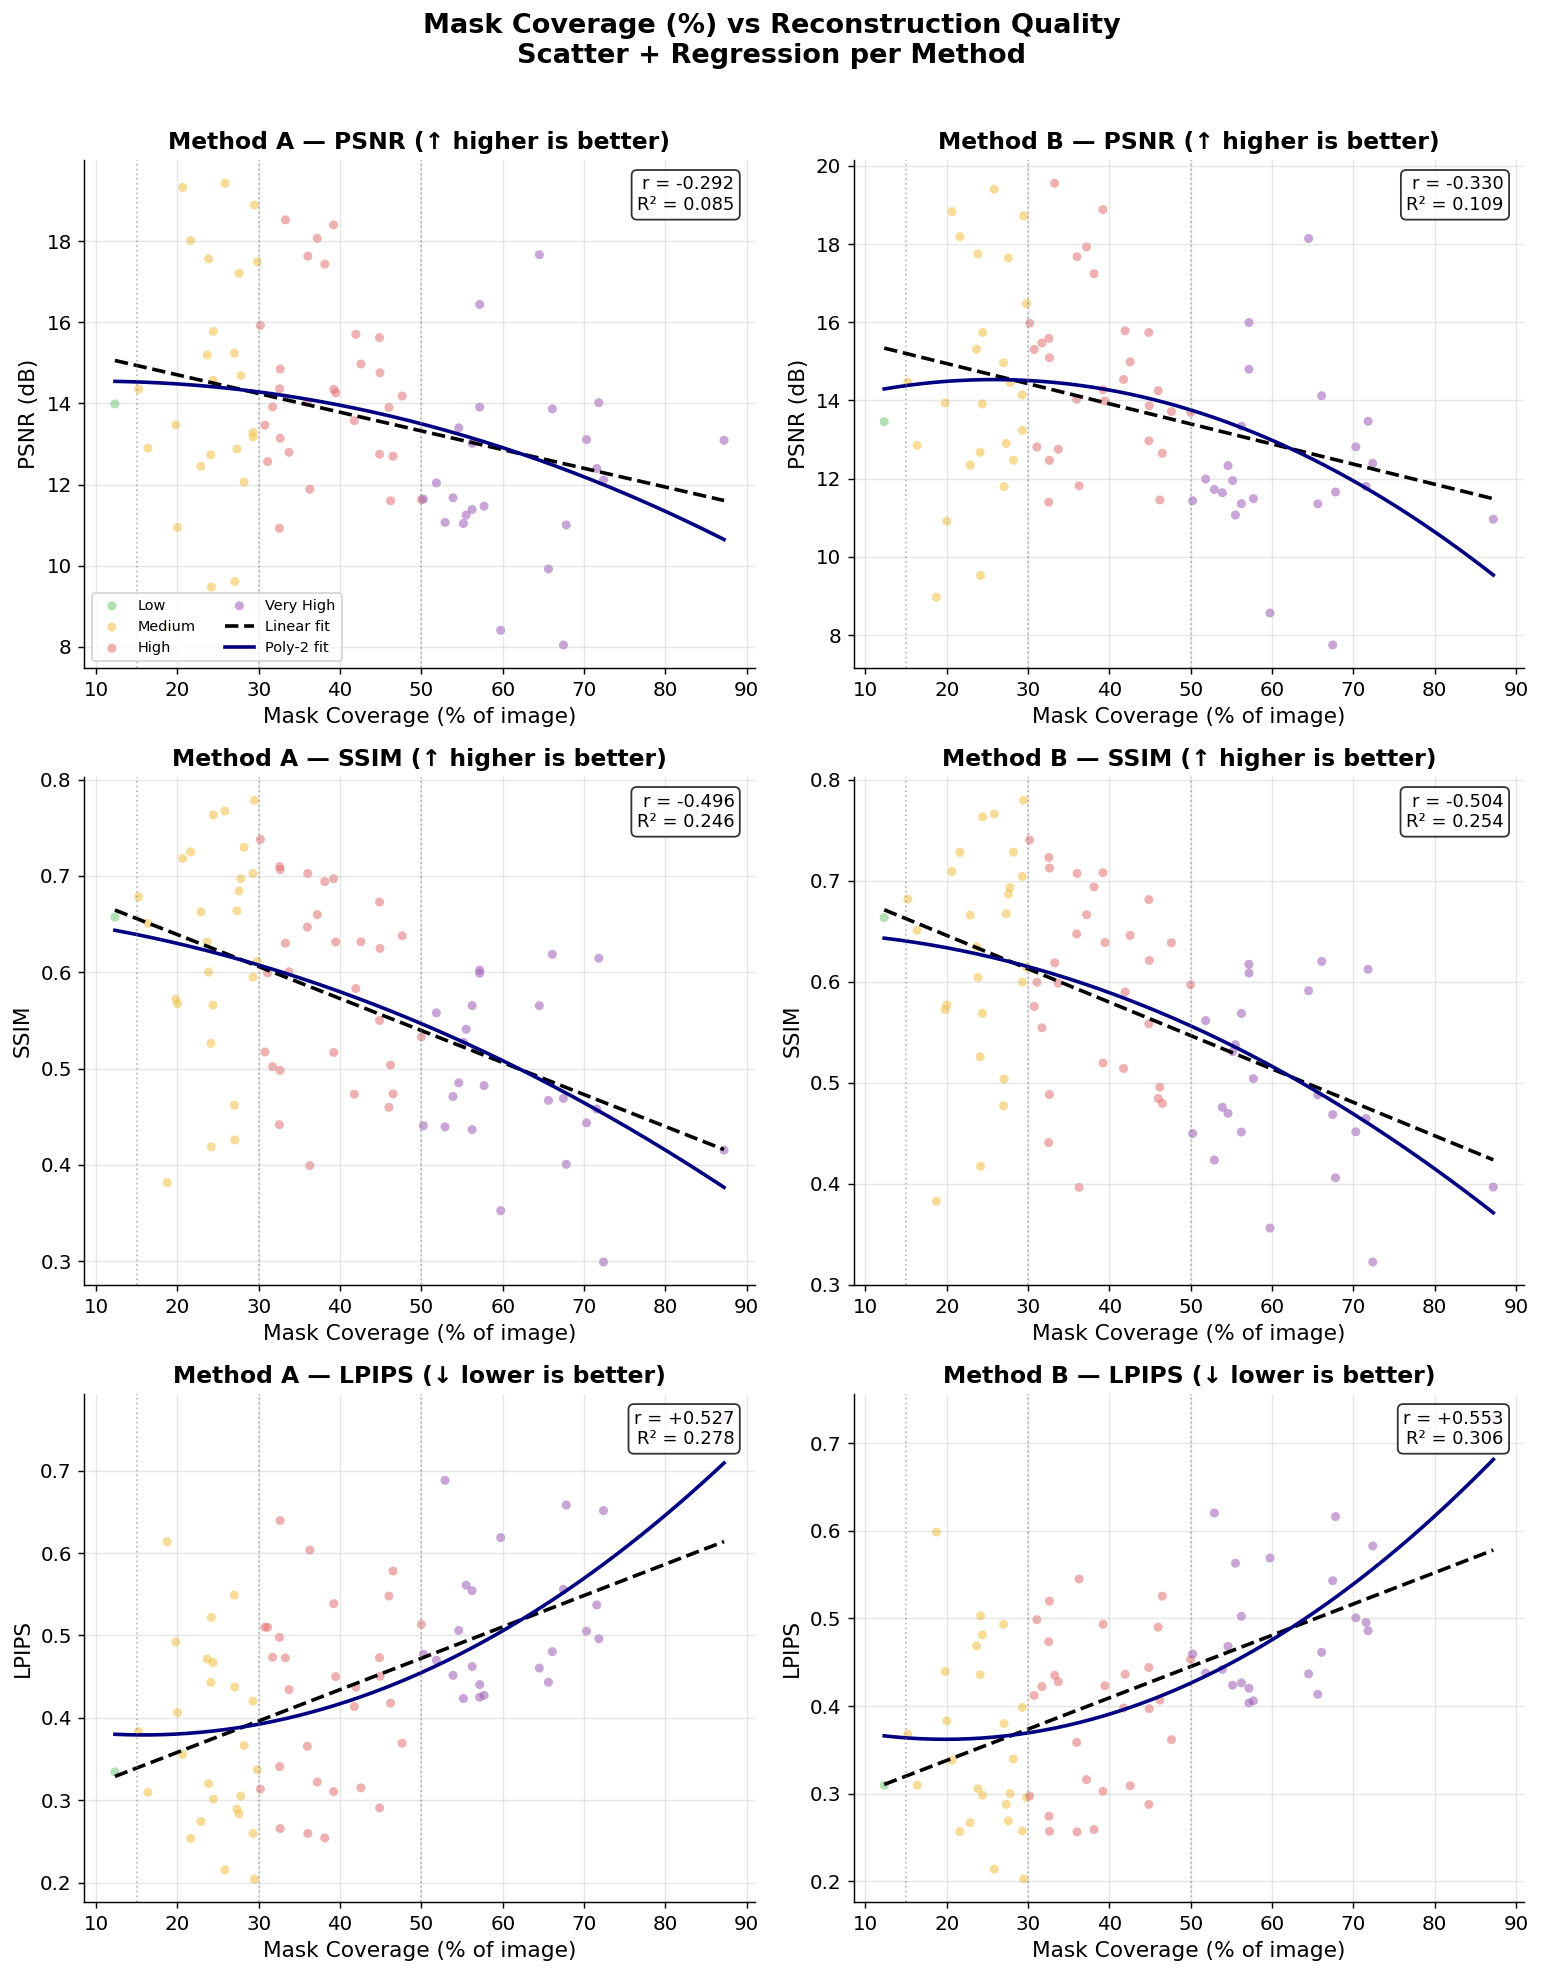

Saved: 02_scatter_regression.png


In [ ]:
metrics_info = [
    ('PSNR',  'PSNR (dB)',   '↑ higher is better'),
    ('SSIM',  'SSIM',        '↑ higher is better'),
    ('LPIPS', 'LPIPS',       '↓ lower is better'),
]

fig, axes = plt.subplots(len(metrics_info), len(methods),
                          figsize=(6*len(methods), 5*len(metrics_info)))
fig.suptitle('Mask Coverage (%) vs Reconstruction Quality\nScatter + Regression per Method',
             fontsize=15, fontweight='bold', y=1.01)

# Make axes 2D if only one method
if len(methods) == 1:
    axes = [[ax] for ax in axes]

for row, (metric, ylabel, hint) in enumerate(metrics_info):
    for col, method in enumerate(methods):
        ax = axes[row][col]
        col_name = f'{method}_{metric}'
        if col_name not in df.columns:
            ax.set_visible(False)
            continue

        x = df['coverage'].values
        y = df[col_name].values
        valid = ~(np.isnan(x)|np.isnan(y))
        x, y = x[valid], y[valid]

        # Scatter colored by area group
        group_colors = {'Low':'#70c775','Medium':'#f0c040','High':'#e07070','Very High':'#9b59b6'}
        groups = pd.cut(x, bins=BINS, labels=SHORT, right=True)
        for g, gc in group_colors.items():
            mask = groups == g
            ax.scatter(x[mask], y[mask], color=gc, alpha=0.55, s=25, label=g, edgecolors='none')

        # Linear regression line
        z = np.polyfit(x, y, 1)
        px = np.linspace(x.min(), x.max(), 200)
        ax.plot(px, np.polyval(z, px), color='black', linewidth=2, linestyle='--', label='Linear fit')

        # Polynomial (degree 2) fit
        z2 = np.polyfit(x, y, 2)
        ax.plot(px, np.polyval(z2, px), color='navy', linewidth=2, linestyle='-', label='Poly-2 fit')

        # R² annotation
        y_pred_lin = np.polyval(z, x)
        r2_lin = r2_score(y, y_pred_lin)
        pr, _ = pearsonr(x, y)
        ax.text(0.97, 0.97, f'r = {pr:+.3f}\nR² = {r2_lin:.3f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        # Threshold lines
        for thresh in [15, 30, 50]:
            ax.axvline(thresh, color='gray', linestyle=':', alpha=0.5, linewidth=1)

        ax.set_title(f'Method {method} — {metric} ({hint})', fontweight='bold')
        ax.set_xlabel('Mask Coverage (% of image)')
        ax.set_ylabel(ylabel)
        if row == 0 and col == 0:
            ax.legend(loc='lower left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(PLOT_DIR/'02_scatter_regression.png', bbox_inches='tight')
plt.show()
print('Saved: 02_scatter_regression.png')

## Cell 7 — Group Mean Comparison: How Metrics Change Across Area Groups

This is the **key table for your paper**. It shows the average PSNR/SSIM/LPIPS for each method, broken down by area group. A clear monotonic drop from Low→Very High proves the area-quality relationship.

  MEAN METRICS BY AREA GROUP
            count  coverage_mean  coverage_std  A_PSNR_mean  A_SSIM_mean  A_LPIPS_mean  B_PSNR_mean  B_SSIM_mean  B_LPIPS_mean  A_PSNR_std  A_SSIM_std  A_LPIPS_std  B_PSNR_std  B_SSIM_std  B_LPIPS_std
area_group                                                                                                                                                                                              
Low             1        12.3100           NaN      13.9870       0.6573        0.3346      13.4560       0.6637        0.3095         NaN         NaN          NaN         NaN         NaN          NaN
Medium         25        24.3352        4.1318      14.3675       0.6231        0.3713      14.4646       0.6282        0.3556      3.0816      0.1123       0.1079      2.8592      0.1063       0.1006
High           29        38.6066        5.9657      14.4102       0.5874        0.4265      14.6857       0.5979        0.3958      2.0840      0.0945       0.1081    

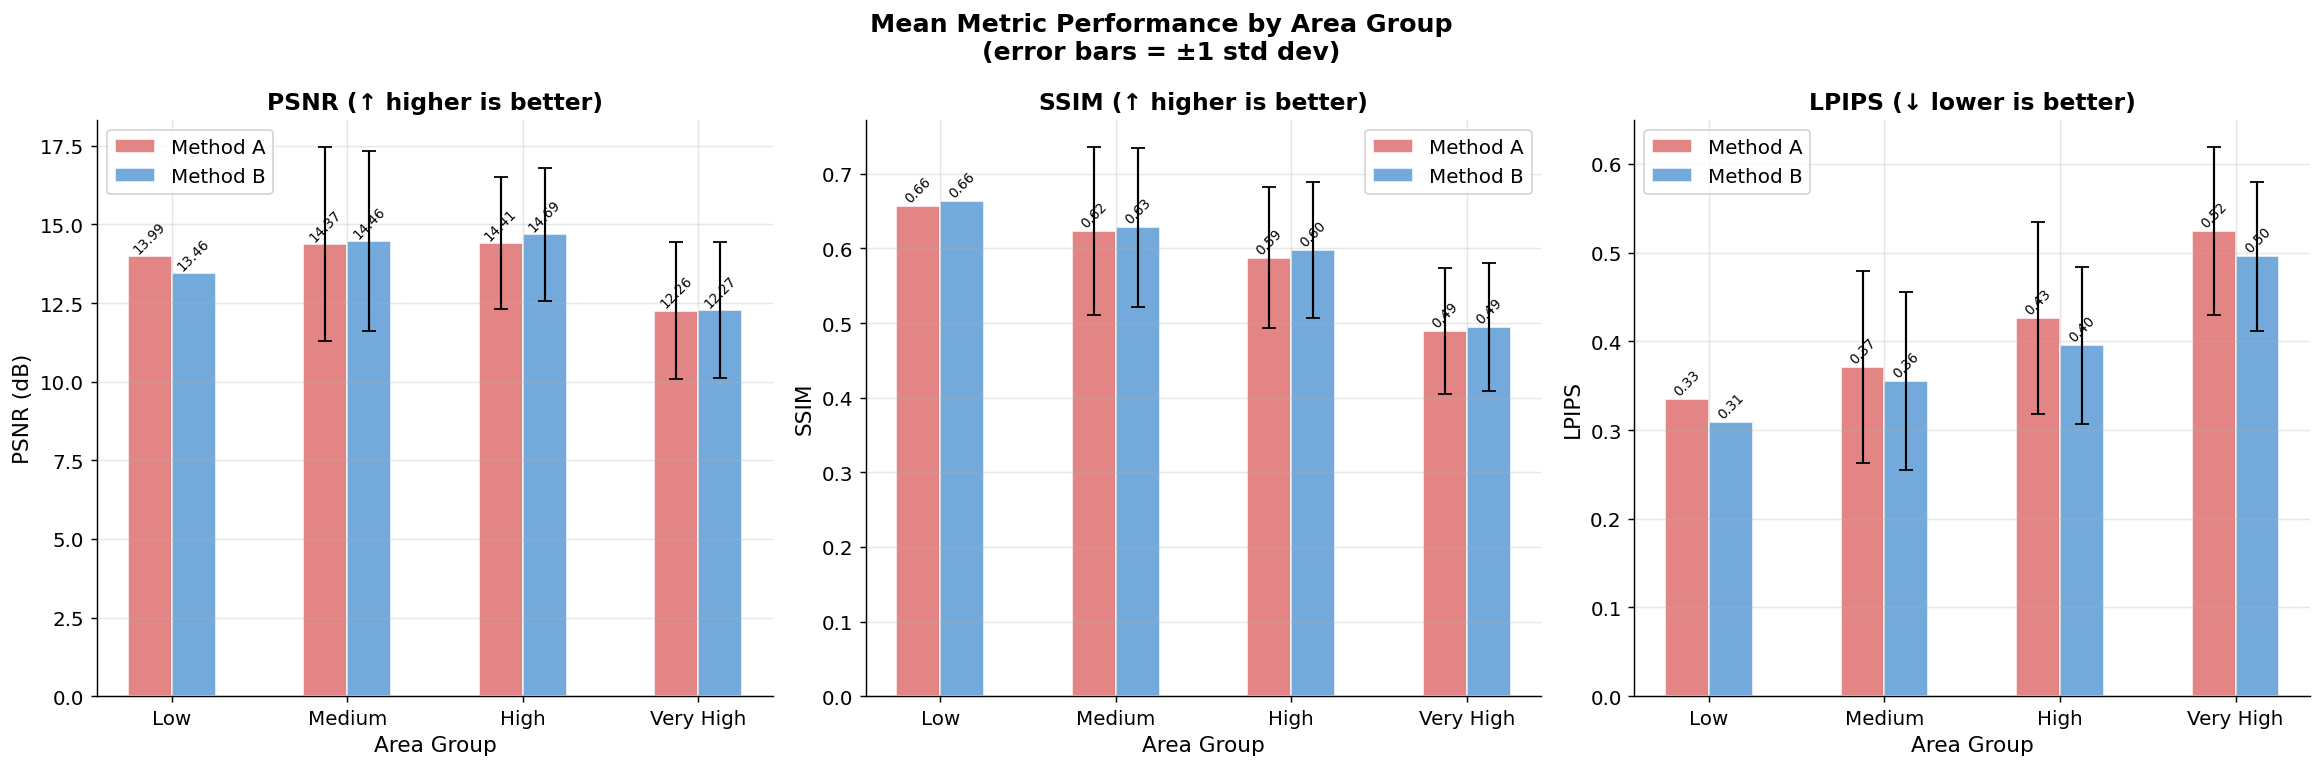

Saved: 03_group_mean_bars.png


  PERCENTAGE CHANGE IN METRICS (Low vs. Very High Coverage Groups)

Method A:
  PSNR: 12.35% drop from Low to Very High coverage.
  SSIM: 25.57% drop from Low to Very High coverage.
  LPIPS: 56.69% increase from Low to Very High coverage.

Method B:
  PSNR: 8.84% drop from Low to Very High coverage.
  SSIM: 25.46% drop from Low to Very High coverage.
  LPIPS: 60.23% increase from Low to Very High coverage.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Compute group means ───────────────────────────────────────────────────────
group_stats = df.groupby('area_group', observed=True).agg(
    count=('coverage', 'count'),
    coverage_mean=('coverage', 'mean'),
    coverage_std=('coverage', 'std'),
    **{f'{m}_{metric}_mean': (f'{m}_{metric}', 'mean')
       for m in methods for metric in ['PSNR','SSIM','LPIPS']
       if f'{m}_{metric}' in df.columns},
    **{f'{m}_{metric}_std': (f'{m}_{metric}', 'std')
       for m in methods for metric in ['PSNR','SSIM','LPIPS']
       if f'{m}_{metric}' in df.columns},
).round(4)

print('='*90)
print('  MEAN METRICS BY AREA GROUP')
print('='*90)
print(group_stats.to_string())
print('='*90)

# ── Bar chart: PSNR by area group for each method ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Mean Metric Performance by Area Group\n(error bars = \u00b11 std dev)',
             fontsize=14, fontweight='bold')

x = np.arange(len(SHORT))
width = 0.25

for ax_idx, (metric, ylabel, hint) in enumerate(metrics_info):
    ax = axes[ax_idx]
    for i, method in enumerate(methods):
        mean_col = f'{method}_{metric}_mean'
        std_col  = f'{method}_{metric}_std'
        if mean_col not in group_stats.columns:
            continue
        means = group_stats[mean_col].values
        stds  = group_stats[std_col].values
        offset = (i - len(methods)/2 + 0.5) * width
        bars = ax.bar(x + offset, means, width, label=f'Method {method}',
                      color=COLORS[method], alpha=0.85, edgecolor='white')
        ax.errorbar(x + offset, means, yerr=stds, fmt='none',
                    color='black', capsize=4, linewidth=1.2)

        # Value labels on bars
        for bar, m in zip(bars, means):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f'{m:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(SHORT)
    ax.set_xlabel('Area Group')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} ({hint})', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR/'03_group_mean_bars.png', bbox_inches='tight')
plt.show()
print('Saved: 03_group_mean_bars.png')

# ── Percentage Change Calculation ─────────────────────────────────────────────
print('\n')
print('='*90)
print('  PERCENTAGE CHANGE IN METRICS (Low vs. Very High Coverage Groups)')
print('='*90)

for method in methods:
    print(f'\nMethod {method}:')
    for metric_name, _, _ in metrics_info:
        col_mean = f'{method}_{metric_name}_mean'
        if col_mean not in group_stats.columns:
            continue

        mean_low = group_stats.loc['Low', col_mean]
        mean_very_high = group_stats.loc['Very High', col_mean]

        if pd.isna(mean_low) or pd.isna(mean_very_high):
            print(f'  {metric_name}: Not enough data for percentage change calculation.')
            continue

        if metric_name in ['PSNR', 'SSIM']: # Higher is better, calculate % drop
            if mean_low == 0:
                pct_change = float('inf') if mean_very_high != 0 else 0
            else:
                pct_change = ((mean_low - mean_very_high) / mean_low) * 100
            status = 'drop' if pct_change > 0 else 'increase'
        else: # LPIPS: Lower is better, calculate % increase
            if mean_low == 0:
                pct_change = float('inf') if mean_very_high != 0 else 0
            else:
                pct_change = ((mean_very_high - mean_low) / mean_low) * 100
            status = 'increase' if pct_change > 0 else 'drop'

        print(f'  {metric_name}: {pct_change:.2f}% {status} from Low to Very High coverage.')


## Cell 8 — Statistical Significance Testing

We use **Kruskal-Wallis test** (non-parametric ANOVA) to check whether the differences across area groups are statistically significant — not just random noise.

Then **Tukey HSD post-hoc** to see which specific group pairs differ significantly.

**For your paper:** If p < 0.05, you can write: *"The Kruskal-Wallis test confirmed a statistically significant effect of mask coverage on PSNR (H=XX, p<0.001), indicating that inpainting quality deterioration with increasing area is not due to random variation."*

In [ ]:
print('='*70)
print('  KRUSKAL-WALLIS TEST: Are group differences statistically significant?')
print('='*70)
print(f'{"Method":<8} {"Metric":<8} {"H-stat":>10} {"p-value":>12}  Significant?')
print('-'*70)

kw_results = []
for method in methods:
    for metric in ['PSNR','SSIM','LPIPS']:
        col = f'{method}_{metric}'
        if col not in df.columns: continue

        groups_data = [df[df['area_group']==g][col].dropna().values for g in SHORT]
        groups_data = [g for g in groups_data if len(g) > 0]
        if len(groups_data) < 2: continue

        H, p = kruskal(*groups_data)
        sig = 'YES ***' if p < 0.001 else ('YES **' if p < 0.01 else ('YES *' if p < 0.05 else 'NO'))
        print(f'{method:<8} {metric:<8} {H:>10.4f} {p:>12.6f}  {sig}')
        kw_results.append({'method':method,'metric':metric,'H':round(H,4),'p':round(p,6),'sig':sig})

print('='*70)
print()

# ── Tukey HSD post-hoc for Method A PSNR (as example) ────────────────────────
if 'A_PSNR' in df.columns and df['area_group'].nunique() > 1:
    print('--- POST-HOC TUKEY HSD: Method A — PSNR ---')
    tukey_df = df[['area_group','A_PSNR']].dropna()
    tukey = pairwise_tukeyhsd(tukey_df['A_PSNR'], tukey_df['area_group'])
    print(tukey)
    print()
    print("Interpretation: 'reject=True' means the two groups have significantly different PSNR.")

  KRUSKAL-WALLIS TEST: Are group differences statistically significant?
Method   Metric       H-stat      p-value  Significant?
----------------------------------------------------------------------
A        PSNR        12.7014     0.005329  YES **
A        SSIM        19.4704     0.000219  YES ***
A        LPIPS       19.9786     0.000171  YES ***
B        PSNR        16.0066     0.001130  YES **
B        SSIM        20.7337     0.000120  YES ***
B        LPIPS       21.0612     0.000102  YES ***

--- POST-HOC TUKEY HSD: Method A — PSNR ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1   group2  meandiff p-adj   lower   upper  reject
-------------------------------------------------------
  High       Low  -0.4232 0.9983 -7.0422  6.1959  False
  High    Medium  -0.0427 0.9999 -1.8188  1.7334  False
  High Very High   -2.151 0.0138 -3.9681 -0.3339   True
   Low    Medium   0.3805 0.9988 -6.2562  7.0172  False
   Low Very High  -1.7278 0.9032 -8.3756    4.92  False
Medi

## Cell 9 — Finding the Critical Degradation Threshold

**This is your novelty finding.** Instead of using fixed bins, we slide a threshold across all possible coverage values and find the exact point where quality drops most sharply.

The threshold where the metric drop is largest = the critical inpainting area limit for your dataset.

  CRITICAL THRESHOLD DETECTION
Method A | PSNR: Critical threshold = 46% (quality drop = 2.2299)
Method A | SSIM: Critical threshold = 67% (quality drop = 0.1405)
Method A | LPIPS: Critical threshold = 71% (quality drop = 0.1853)
Method B | PSNR: Critical threshold = 67% (quality drop = 2.5688)
Method B | SSIM: Critical threshold = 67% (quality drop = 0.1450)
Method B | LPIPS: Critical threshold = 71% (quality drop = 0.1707)


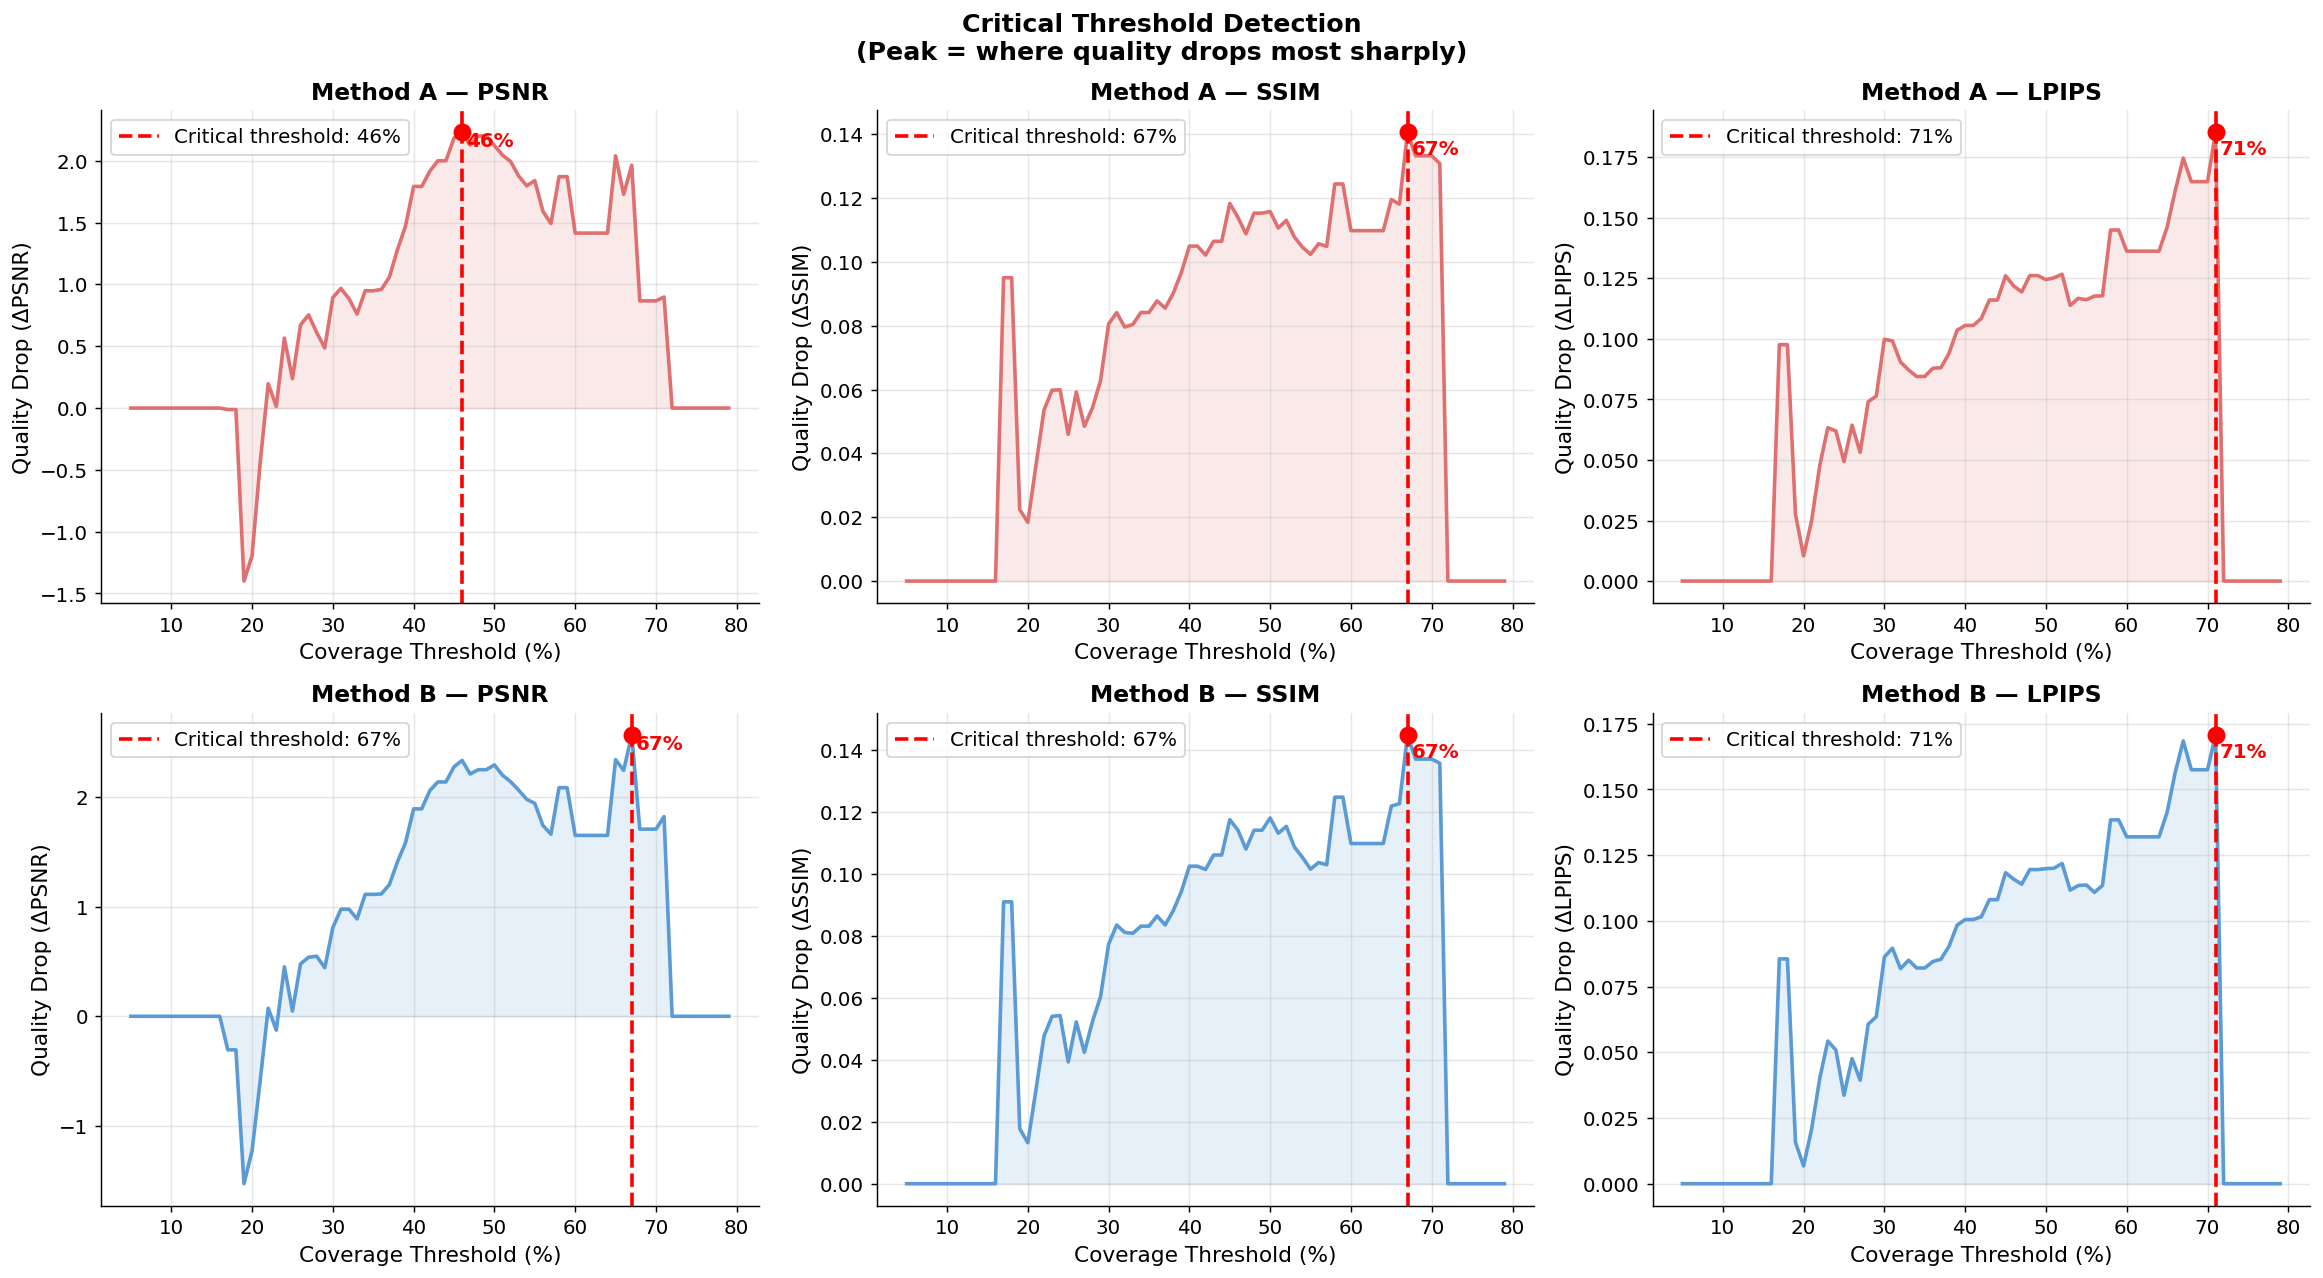


Saved: 04_critical_threshold.png


In [ ]:
print('='*60)
print('  CRITICAL THRESHOLD DETECTION')
print('='*60)

# Sort by coverage
df_sorted = df.sort_values('coverage').reset_index(drop=True)

# For each possible threshold (5% to 80%), compute mean metric below vs above
thresholds = np.arange(5, 80, 1)

threshold_results = {}
for method in methods:
    for metric in ['PSNR','SSIM','LPIPS']:
        col = f'{method}_{metric}'
        if col not in df.columns: continue
        diffs = []
        for t in thresholds:
            below = df_sorted[df_sorted['coverage'] <= t][col].dropna()
            above = df_sorted[df_sorted['coverage'] > t][col].dropna()
            if len(below) < 3 or len(above) < 3:
                diffs.append(0)
            else:
                # For LPIPS: above should be HIGHER (worse), so diff = above - below
                # For PSNR/SSIM: above should be LOWER (worse), so diff = below - above
                if metric == 'LPIPS':
                    diffs.append(above.mean() - below.mean())
                else:
                    diffs.append(below.mean() - above.mean())
        threshold_results[(method, metric)] = np.array(diffs)

# ── Plot threshold analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(len(methods), 3, figsize=(18, 5*len(methods)))
fig.suptitle('Critical Threshold Detection\n(Peak = where quality drops most sharply)',
             fontsize=14, fontweight='bold')

if len(methods) == 1:
    axes = [axes]

for row, method in enumerate(methods):
    for col_idx, (metric, _, _) in enumerate(metrics_info):
        ax = axes[row][col_idx]
        key = (method, metric)
        if key not in threshold_results:
            ax.set_visible(False); continue

        diffs = threshold_results[key]
        best_t = thresholds[np.argmax(diffs)]
        best_diff = diffs.max()

        ax.plot(thresholds, diffs, color=COLORS[method], linewidth=2)
        ax.fill_between(thresholds, 0, diffs, alpha=0.15, color=COLORS[method])
        ax.axvline(best_t, color='red', linestyle='--', linewidth=2,
                   label=f'Critical threshold: {best_t}%')
        ax.scatter([best_t],[best_diff], color='red', zorder=5, s=80)
        ax.text(best_t+0.5, best_diff*0.95, f'{best_t}%',
                color='red', fontweight='bold', fontsize=11)
        ax.set_xlabel('Coverage Threshold (%)')
        ax.set_ylabel(f'Quality Drop (Δ{metric})')
        ax.set_title(f'Method {method} — {metric}', fontweight='bold')
        ax.legend()

        print(f'Method {method} | {metric}: Critical threshold = {best_t}% '
              f'(quality drop = {best_diff:.4f})')

plt.tight_layout()
plt.savefig(PLOT_DIR/'04_critical_threshold.png', bbox_inches='tight')
plt.show()
print('\nSaved: 04_critical_threshold.png')

## Cell 10 — Regression Analysis: Quantify the Relationship

We fit three models (Linear, Polynomial-2, Polynomial-3) to quantify how strongly area predicts metric quality.  
**R² score** tells you how much of the metric variance is explained by area alone.

**For your paper:** *"Coverage area alone explains X% of the variance in PSNR (R²=X), confirming it as the dominant factor in inpainting quality."*

In [ ]:
print('='*75)
print('  REGRESSION ANALYSIS: R² of Coverage → Metric')
print('='*75)
print(f'{"Method":<8} {"Metric":<8} {"Linear R²":>12} {"Poly-2 R²":>12} {"Poly-3 R²":>12}  Best Fit')
print('-'*75)

reg_results = []

for method in methods:
    for metric in ['PSNR','SSIM','LPIPS']:
        col = f'{method}_{metric}'
        if col not in df.columns: continue
        x = df['coverage'].values.reshape(-1,1)
        y = df[col].values
        valid = ~np.isnan(y)
        x, y = x[valid], y[valid]

        r2s = []
        for deg in [1, 2, 3]:
            pf = PolynomialFeatures(degree=deg, include_bias=False)
            Xp = pf.fit_transform(x)
            model = LinearRegression().fit(Xp, y)
            y_pred = model.predict(Xp)
            r2s.append(r2_score(y, y_pred))

        best = ['Linear','Poly-2','Poly-3'][np.argmax(r2s)]
        print(f'{method:<8} {metric:<8} {r2s[0]:>12.4f} {r2s[1]:>12.4f} {r2s[2]:>12.4f}  {best}')
        reg_results.append({'method':method,'metric':metric,
                            'R2_linear':round(r2s[0],4),
                            'R2_poly2': round(r2s[1],4),
                            'R2_poly3': round(r2s[2],4),
                            'best_fit': best})

print('='*75)
print('R² closer to 1.0 = coverage area is a strong predictor of that metric')

  REGRESSION ANALYSIS: R² of Coverage → Metric
Method   Metric      Linear R²    Poly-2 R²    Poly-3 R²  Best Fit
---------------------------------------------------------------------------
A        PSNR           0.0851       0.0907       0.1446  Poly-3
A        SSIM           0.2456       0.2509       0.2580  Poly-3
A        LPIPS          0.2780       0.3046       0.3050  Poly-3
B        PSNR           0.1091       0.1330       0.1712  Poly-3
B        SSIM           0.2543       0.2641       0.2698  Poly-3
B        LPIPS          0.3063       0.3455       0.3456  Poly-3
R² closer to 1.0 = coverage area is a strong predictor of that metric


## Cell 11 — Method Comparison: Does Progressive Removal Help More at High Coverage?

**This is the most important finding for your research.**  
At low coverage, Methods A, B, C may all perform similarly.  
At HIGH coverage (the hard cases), does progressive removal (B or C) outperform single-shot (A) by a larger margin?  
If yes → progressive removal is specifically beneficial for large-mask cases.

  METHOD ADVANTAGE BY AREA GROUP
  (Positive = B/C better than A; bigger gap at high coverage = novelty!)
  PSNR | Method B vs A | Low       : Δ = -0.5310 ± nan
  PSNR | Method B vs A | Medium    : Δ = +0.0971 ± 0.5805
  PSNR | Method B vs A | High      : Δ = +0.2755 ± 0.7011
  PSNR | Method B vs A | Very High : Δ = +0.0076 ± 0.7329

  SSIM | Method B vs A | Low       : Δ = +0.0064 ± nan
  SSIM | Method B vs A | Medium    : Δ = +0.0051 ± 0.0158
  SSIM | Method B vs A | High      : Δ = +0.0105 ± 0.0195
  SSIM | Method B vs A | Very High : Δ = +0.0055 ± 0.0120

  LPIPS | Method B vs A | Low       : Δ = +0.0251 ± nan
  LPIPS | Method B vs A | Medium    : Δ = +0.0157 ± 0.0188
  LPIPS | Method B vs A | High      : Δ = +0.0307 ± 0.0308
  LPIPS | Method B vs A | Very High : Δ = +0.0284 ± 0.0195



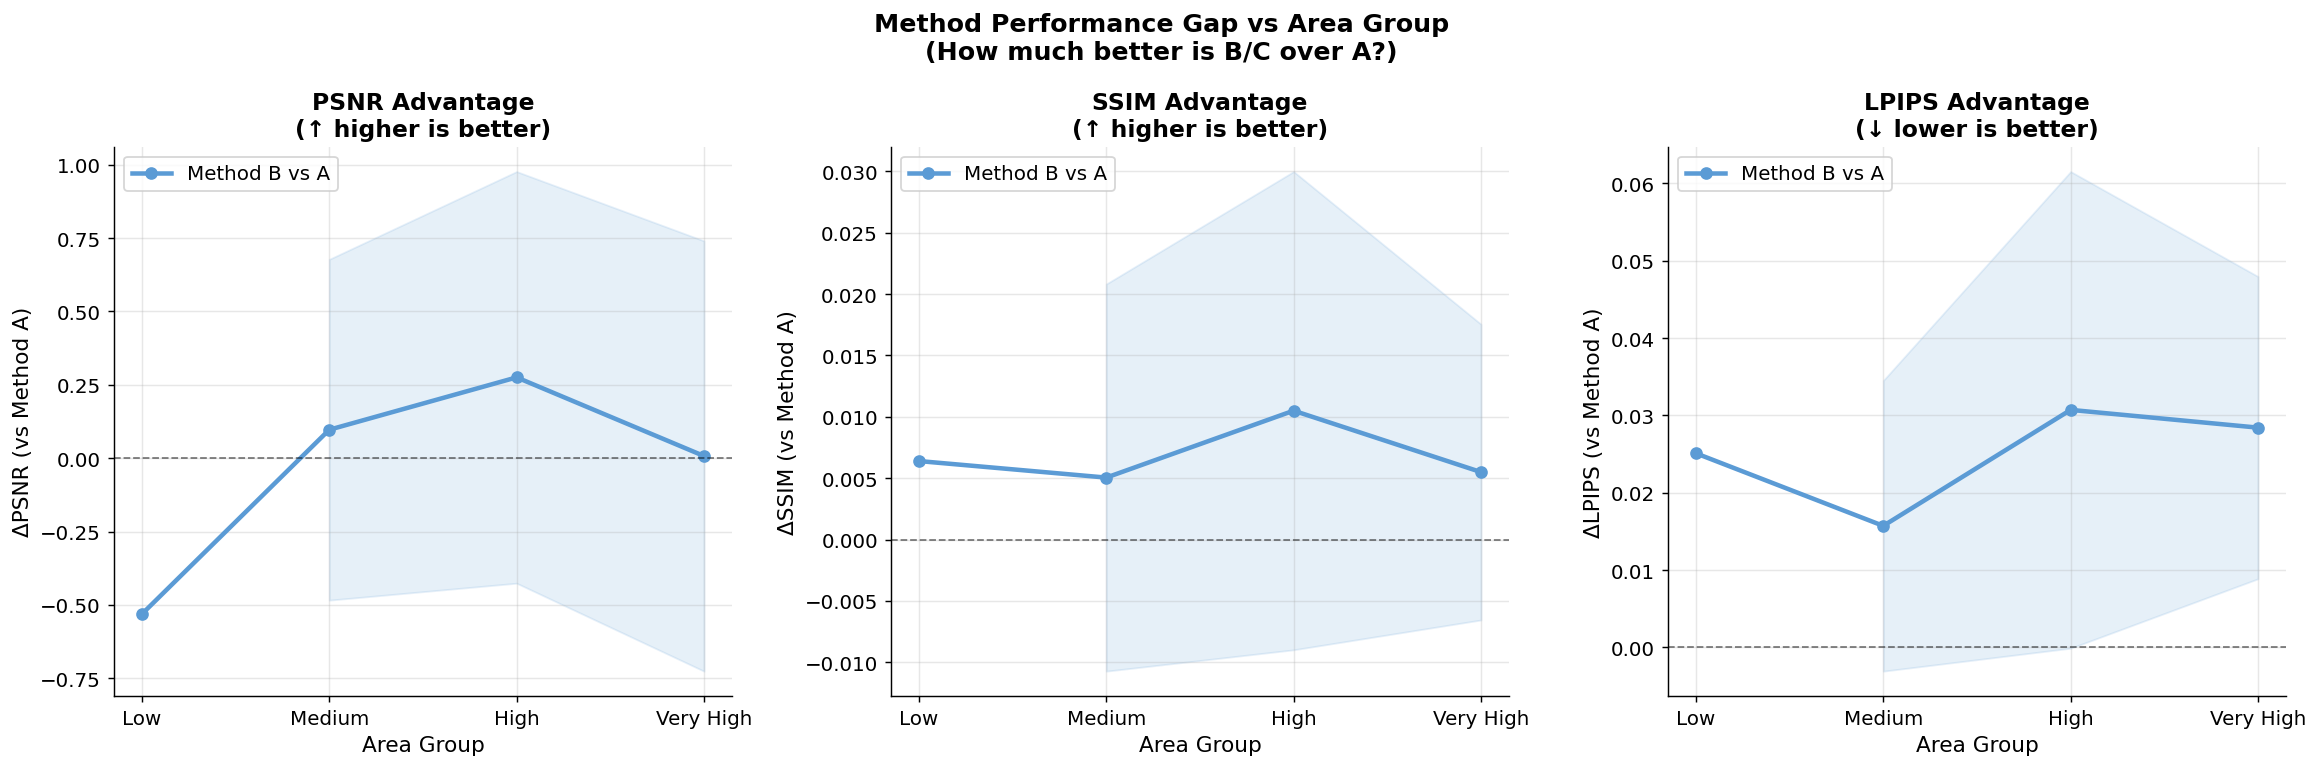

Saved: 05_method_advantage_by_group.png


In [ ]:
if len(methods) >= 2:
    print('='*70)
    print('  METHOD ADVANTAGE BY AREA GROUP')
    print('  (Positive = B/C better than A; bigger gap at high coverage = novelty!)')
    print('='*70)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Method Performance Gap vs Area Group\n(How much better is B/C over A?)',
                 fontsize=14, fontweight='bold')

    for ax_idx, (metric, ylabel, hint) in enumerate(metrics_info):
        ax = axes[ax_idx]
        a_col = f'A_{metric}'
        if a_col not in df.columns: continue

        for method in [m for m in methods if m != 'A']:
            col = f'{method}_{metric}'
            if col not in df.columns: continue

            # Compute per-group advantage of method over A
            gap_means = []
            gap_stds  = []
            for g in SHORT:
                sub = df[df['area_group'] == g]
                if len(sub) == 0:
                    gap_means.append(0); gap_stds.append(0); continue
                # For LPIPS: negative gap = method is LOWER (better)
                # For PSNR/SSIM: positive gap = method is HIGHER (better)
                if metric == 'LPIPS':
                    gap = sub[a_col] - sub[col]  # positive = method better
                else:
                    gap = sub[col] - sub[a_col]  # positive = method better
                gap_means.append(gap.mean())
                gap_stds.append(gap.std())

            x_pos = np.arange(len(SHORT))
            ax.plot(x_pos, gap_means, marker='o', linewidth=2.5,
                    color=COLORS[method], label=f'Method {method} vs A')
            ax.fill_between(x_pos,
                            np.array(gap_means)-np.array(gap_stds),
                            np.array(gap_means)+np.array(gap_stds),
                            alpha=0.15, color=COLORS[method])

            for xi, (gm, gs) in enumerate(zip(gap_means, gap_stds)):
                print(f'  {metric} | Method {method} vs A | {SHORT[xi]:10s}: Δ = {gm:+.4f} ± {gs:.4f}')

        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(SHORT)))
        ax.set_xticklabels(SHORT)
        ax.set_xlabel('Area Group')
        ax.set_ylabel(f'Δ{metric} (vs Method A)')
        ax.set_title(f'{metric} Advantage\n({hint})', fontweight='bold')
        ax.legend()
        print()

    plt.tight_layout()
    plt.savefig(PLOT_DIR/'05_method_advantage_by_group.png', bbox_inches='tight')
    plt.show()
    print('Saved: 05_method_advantage_by_group.png')
else:
    print('Only one method found — skipping comparison.')

## Cell 12 — Boxplots by Area Group
Shows the full distribution (median, IQR, outliers) of each metric for each area group — more informative than just means.

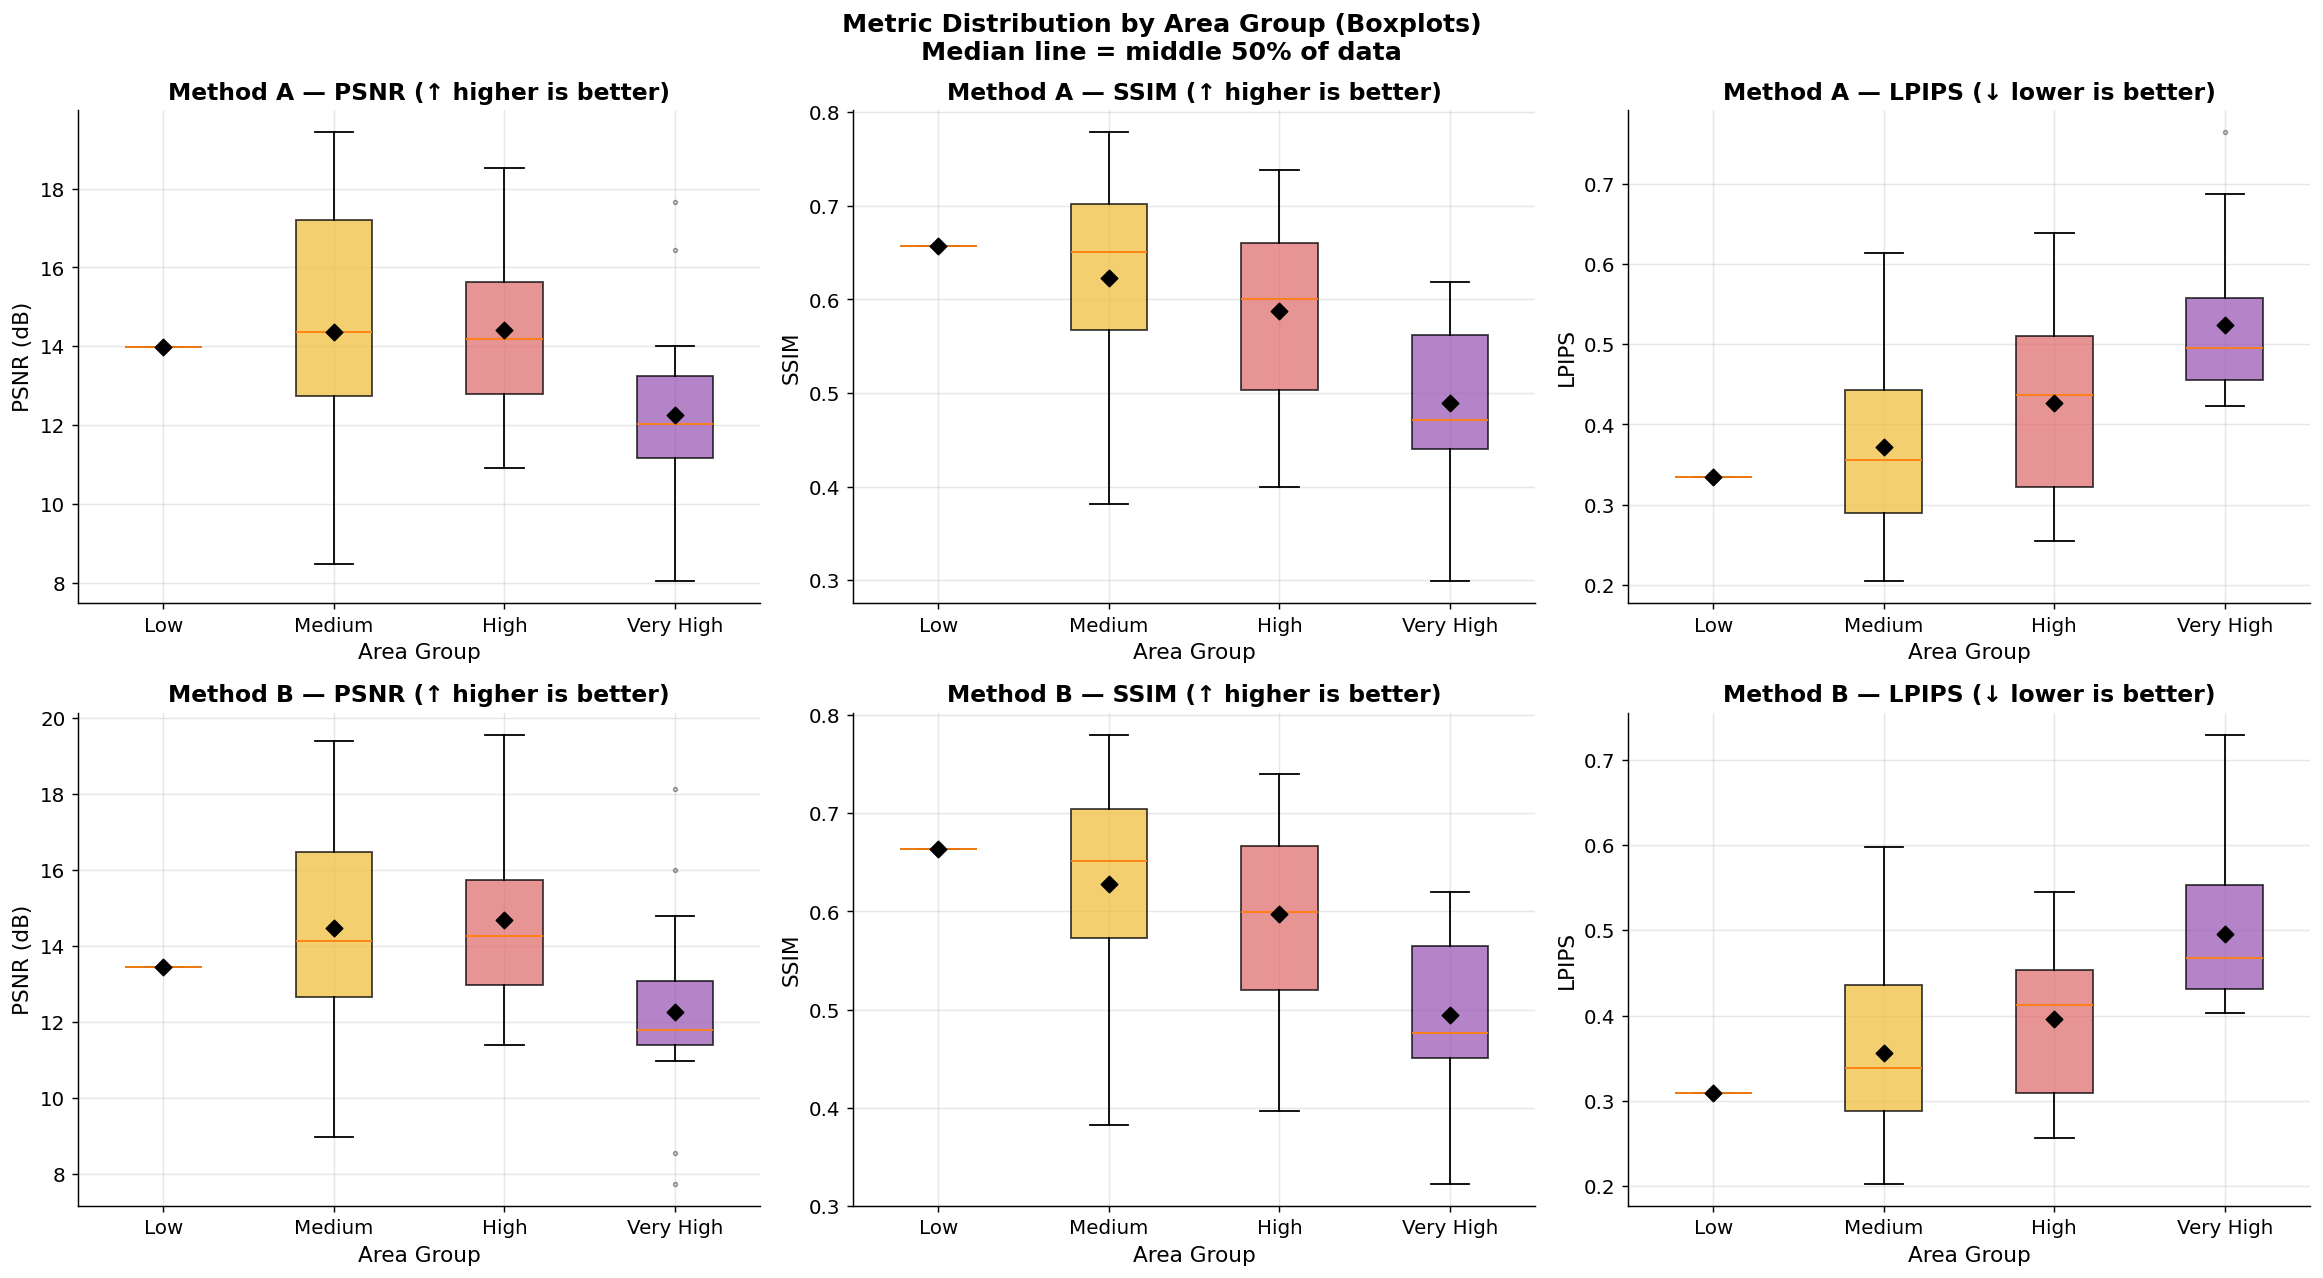

Saved: 06_boxplots_by_group.png


In [ ]:
fig, axes = plt.subplots(len(methods), 3, figsize=(18, 5*len(methods)))
fig.suptitle('Metric Distribution by Area Group (Boxplots)\nMedian line = middle 50% of data',
             fontsize=14, fontweight='bold')

if len(methods) == 1:
    axes = [axes]

box_palette = {'Low':'#70c775','Medium':'#f0c040','High':'#e07070','Very High':'#9b59b6'}

for row, method in enumerate(methods):
    for col_idx, (metric, ylabel, hint) in enumerate(metrics_info):
        ax = axes[row][col_idx]
        col = f'{method}_{metric}'
        if col not in df.columns:
            ax.set_visible(False); continue

        data_by_group = [df[df['area_group']==g][col].dropna().values for g in SHORT]
        bp = ax.boxplot(data_by_group, labels=SHORT, patch_artist=True,
                        notch=False, showfliers=True,
                        flierprops=dict(marker='.', alpha=0.4, markersize=4))
        colors = ['#70c775','#f0c040','#e07070','#9b59b6']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        # Add mean dots
        for i, g in enumerate(SHORT):
            sub = df[df['area_group']==g][col].dropna()
            if len(sub) > 0:
                ax.scatter(i+1, sub.mean(), color='black', zorder=5, s=40, marker='D')

        ax.set_xlabel('Area Group')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Method {method} — {metric} ({hint})', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR/'06_boxplots_by_group.png', bbox_inches='tight')
plt.show()
print('Saved: 06_boxplots_by_group.png')

## Cell 13 — Heatmap: Correlation Matrix
Visualises correlation between ALL metrics and coverage at once — good for paper figures.

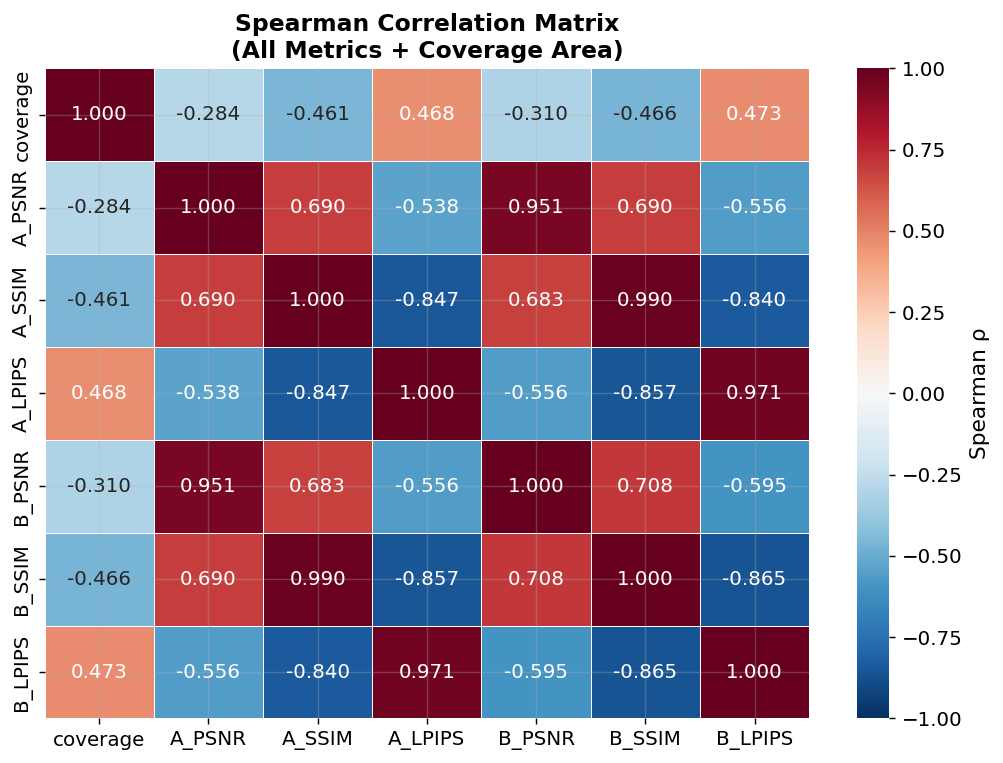

Saved: 07_correlation_heatmap.png


In [ ]:
# Build correlation matrix
corr_cols = ['coverage'] + [f'{m}_{metric}' for m in methods
                              for metric in ['PSNR','SSIM','LPIPS']
                              if f'{m}_{metric}' in df.columns]
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols)-2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle only

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Spearman Correlation Matrix\n(All Metrics + Coverage Area)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR/'07_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 07_correlation_heatmap.png')

## Cell 14 — Final Summary Table for Paper
Generates a clean, paper-ready table showing all key numbers in one place.

In [ ]:
print('='*90)
print('  FINAL SUMMARY TABLE — Ready for Paper')
print('='*90)

# Per-group metric means for each method
for metric in ['PSNR','SSIM','LPIPS']:
    print(f'\n  {metric}:')
    header = f'{"Area Group":<15} {"Coverage %":>12}'
    for m in methods:
        header += f'  {f"Method {m}":>12}'
    print('  ' + header)
    print('  ' + '-'*60)
    for g in SHORT:
        sub = df[df['area_group']==g]
        cov = f"{sub['coverage'].mean():.1f} ± {sub['coverage'].std():.1f}"
        row = f'{g:<15} {cov:>12}'
        for m in methods:
            col = f'{m}_{metric}'
            if col in df.columns:
                val = f"{sub[col].mean():.3f}"
            else:
                val = 'N/A'
            row += f'  {val:>12}'
        print('  ' + row)

print()
print('='*90)
print('  CORRELATION SUMMARY (Spearman ρ, Coverage vs Metric)')
print('='*90)
print(f'{"Method":<8} {"PSNR ρ":>10} {"SSIM ρ":>10} {"LPIPS ρ":>10}')
print('-'*40)
for method in methods:
    row = f'{method:<8}'
    for metric in ['PSNR','SSIM','LPIPS']:
        match = corr_df[(corr_df['method']==method) & (corr_df['metric']==metric)]
        if len(match) > 0:
            row += f'  {match.iloc[0]["spearman_r"]:>+8.4f}'
        else:
            row += f'  {"N/A":>10}'
    print(row)
print('='*90)

# Save summary to CSV
summary_out = []
for g in SHORT:
    sub = df[df['area_group']==g]
    row_dict = {
        'area_group': g,
        'n_images': len(sub),
        'coverage_mean': round(sub['coverage'].mean(),2),
        'coverage_std': round(sub['coverage'].std(),2),
    }
    for m in methods:
        for metric in ['PSNR','SSIM','LPIPS']:
            col = f'{m}_{metric}'
            if col in df.columns:
                row_dict[f'{m}_{metric}_mean'] = round(sub[col].mean(),4)
                row_dict[f'{m}_{metric}_std']  = round(sub[col].std(),4)
    summary_out.append(row_dict)

summary_df = pd.DataFrame(summary_out)
summary_df.to_csv(PLOT_DIR/'summary_table.csv', index=False)
print(f'\nSaved summary table → {PLOT_DIR}/summary_table.csv')
print('\nAll plots saved in:', str(PLOT_DIR))
print('\nPlots generated:')
for f in sorted(PLOT_DIR.glob('*.png')):
    print(f'  {f.name}')

  FINAL SUMMARY TABLE — Ready for Paper

  PSNR:
  Area Group        Coverage %      Method A      Method B
  ------------------------------------------------------------
  Low               12.3 ± nan        13.987        13.456
  Medium            24.3 ± 4.1        14.367        14.465
  High              38.6 ± 6.0        14.410        14.686
  Very High         61.9 ± 9.0        12.259        12.267

  SSIM:
  Area Group        Coverage %      Method A      Method B
  ------------------------------------------------------------
  Low               12.3 ± nan         0.657         0.664
  Medium            24.3 ± 4.1         0.623         0.628
  High              38.6 ± 6.0         0.587         0.598
  Very High         61.9 ± 9.0         0.489         0.495

  LPIPS:
  Area Group        Coverage %      Method A      Method B
  ------------------------------------------------------------
  Low               12.3 ± nan         0.335         0.309
  Medium            24.3 ± 4.1     

## Cell 15 — What to Tell Your Faculty

Run this cell to get a plain-English interpretation of all your results.

In [ ]:
print()
print('='*70)
print('  INTERPRETATION GUIDE — What to tell your faculty')
print('='*70)

print('''
1. CORRELATION (Cell 5):
   - A Spearman ρ close to -1 for PSNR/SSIM means: as more area is masked,
     quality drops strongly and consistently across all 200 images.
   - A Spearman ρ close to +1 for LPIPS means: more area → worse perceptual quality.
   - p < 0.001 (***) means this is not by chance — it is a real, reproducible trend.

2. AREA GROUPS (Cell 7):
   - You can see exactly how much PSNR/SSIM drops and LPIPS rises
     as you go from Low → Medium → High → Very High coverage.
   - The error bars show spread — narrow bars mean consistent behavior.

3. CRITICAL THRESHOLD (Cell 9):
   - The red line shows the specific coverage % where quality drops most sharply.
   - Example: if the threshold is 32%, images with >32% masked area are
     significantly harder to inpaint than those below 32%.
   - This is your NOVELTY: a data-driven, dataset-specific quality threshold.

4. REGRESSION R² (Cell 10):
   - R² = 0.6 means 60% of the variance in PSNR is explained by coverage area alone.
   - This proves area is the dominant factor, not just one of many.

5. METHOD ADVANTAGE (Cell 11):
   - If Method B/C advantage GROWS as area group increases,
     it proves progressive removal specifically helps the hard large-mask cases.
   - If the advantage is flat, both methods struggle equally at high coverage.

6. FOR YOUR PAPER (suggested sentence):
   "Our statistical analysis over 200 images reveals a strong negative Spearman
   correlation (ρ = -0.XX, p < 0.001) between mask coverage area and PSNR,
   confirming that inpainting quality degrades consistently with increasing
   removal area. A critical degradation threshold was identified at XX% coverage,
   beyond which mean PSNR drops by X dB compared to lower-coverage images.
   Progressive instance removal (Method B/C) demonstrates an increasing
   advantage over single-shot removal (Method A) in the high-coverage regime
   (>30%), suggesting it partially compensates for the area-driven quality loss."
''')
print('='*70)


  INTERPRETATION GUIDE — What to tell your faculty

1. CORRELATION (Cell 5):
   - A Spearman ρ close to -1 for PSNR/SSIM means: as more area is masked,
     quality drops strongly and consistently across all 200 images.
   - A Spearman ρ close to +1 for LPIPS means: more area → worse perceptual quality.
   - p < 0.001 (***) means this is not by chance — it is a real, reproducible trend.

2. AREA GROUPS (Cell 7):
   - You can see exactly how much PSNR/SSIM drops and LPIPS rises
     as you go from Low → Medium → High → Very High coverage.
   - The error bars show spread — narrow bars mean consistent behavior.

3. CRITICAL THRESHOLD (Cell 9):
   - The red line shows the specific coverage % where quality drops most sharply.
   - Example: if the threshold is 32%, images with >32% masked area are
     significantly harder to inpaint than those below 32%.
   - This is your NOVELTY: a data-driven, dataset-specific quality threshold.

4. REGRESSION R² (Cell 10):
   - R² = 0.6 means 60% of the